# 01 — EDA and Preprocessing

Dataset: `laotse/credit-risk-dataset` (`data/raw/credit_risk_dataset.csv`).

This notebook documents every EDA finding that drives a cleaning decision, applies
the cleaning via `src/preprocessing.py` (so training and serving code reuse the same
logic — no train/serve skew), and produces the 60/20/20 train/val/test split used by
every downstream notebook.

Run top to bottom. Outputs: `data/processed/{train,val,test}.csv`.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from src.preprocessing import load_raw, clean, get_feature_target, TARGET, CATEGORICAL_COLS, NUMERIC_COLS

pd.set_option('display.width', 120)
sns.set_style('whitegrid')

## 1. Load and shape check

In [2]:
df = load_raw('../data/raw/credit_risk_dataset.csv')
print('shape:', df.shape)
df.head()

shape: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


loan_status
0    0.781836
1    0.218164
Name: proportion, dtype: float64


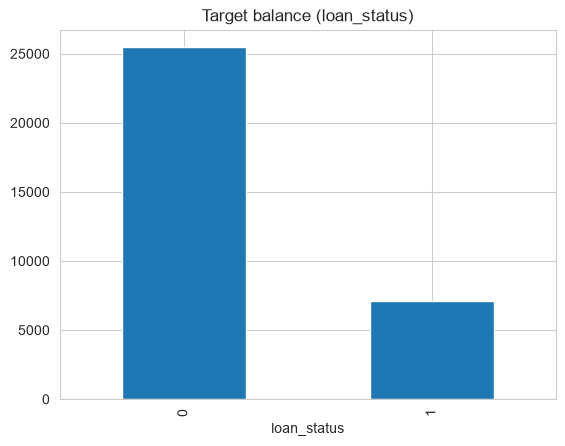

In [3]:
print(df[TARGET].value_counts(normalize=True))
df[TARGET].value_counts().plot(kind='bar', title='Target balance (loan_status)')
plt.show()

**Finding:** 78.2% repaid / 21.8% default. Imbalanced enough that accuracy stays a
trap (predicting 'no default' for everyone scores 78.2%) — AUC/KS/Brier are used
throughout instead, per `src/metrics.py`.

## 2. Missingness

In [4]:
missing = df.isnull().mean().sort_values(ascending=False)
print(missing[missing > 0])

loan_int_rate        0.095639
person_emp_length    0.027470
dtype: float64


**Finding:** `loan_int_rate` ~9.6% missing, `person_emp_length` ~2.7% missing.
Both are moderate and will be **median-imputed, fit on the training split only**
(Section 6) — no global-statistic leakage into val/test.

## 3. Outlier / data-quality checks

In [5]:
print('duplicate rows:', df.duplicated().sum())
print()
print('person_age > 80 (implausible):')
print(df[df.person_age > 80][['person_age', 'person_emp_length', 'person_income', TARGET]])
print()
print('person_emp_length > person_age (impossible):')
print(df[df.person_emp_length > df.person_age][['person_age', 'person_emp_length']])

duplicate rows: 165

person_age > 80 (implausible):
       person_age  person_emp_length  person_income  loan_status
81            144                4.0         250000            0
183           144                4.0         200000            0
575           123                2.0          80004            0
747           123                7.0          78000            0
32297         144               12.0        6000000            0
32416          94                1.0          24000            0
32506          84                2.0          94800            0

person_emp_length > person_age (impossible):
     person_age  person_emp_length
0            22              123.0
210          21              123.0


**Findings (each drives a documented cleaning rule in `src/preprocessing.py`):**
- **165 exact duplicate rows** — dropped, to avoid the same record landing in both
  train and test after splitting.
- **7 rows with `person_age` in [84, 144]** — physically implausible (max human
  lifespan), clear data-entry errors rather than a coded sentinel (no single
  repeated value, unlike Home Credit's `DAYS_EMPLOYED=365243`). Capped, not dropped
  (too few rows to justify losing the rest of their information).
- **2 rows with `person_emp_length` (123) exceeding `person_age` (21-22)** —
  logically impossible. Capped at `age - 14` (minimum plausible working age).

## 4. Default rate by categorical variable (informal IV preview — formal IV/WOE in notebook 02)

In [6]:
for col in CATEGORICAL_COLS:
    print(f'--- {col} ---')
    print(df.groupby(col)[TARGET].agg(['mean', 'count']).sort_values('mean'))
    print()

--- person_home_ownership ---
                           mean  count
person_home_ownership                 
OWN                    0.074690   2584
MORTGAGE               0.125707  13444
OTHER                  0.308411    107
RENT                   0.315700  16446

--- loan_intent ---
                       mean  count
loan_intent                       
VENTURE            0.148103   5719
EDUCATION          0.172168   6453
PERSONAL           0.198877   5521
HOMEIMPROVEMENT    0.261026   3605
MEDICAL            0.267007   6071
DEBTCONSOLIDATION  0.285879   5212

--- loan_grade ---
                mean  count
loan_grade                 
A           0.099564  10777
B           0.162760  10451
C           0.207340   6458
D           0.590458   3626
E           0.644191    964
F           0.705394    241
G           0.984375     64

--- cb_person_default_on_file ---
                               mean  count
cb_person_default_on_file                 
N                          0.183932  26836

**Finding — `loan_grade` is very strongly predictive on its own:** default rate
rises monotonically from 9.96% (grade A) to 98.4% (grade G). This is expected —
`loan_grade` is the lender's own risk rating, assigned at underwriting (available
before/at the same time as the loan decision, not a post-outcome leak). But because
it's so strongly predictive, it will likely dominate feature importance/IV and risks
making the exercise reduce to 'predict the lender's own grade'.

**Decision:** keep `loan_grade` in the primary model (a real deployment would have
it), but also train a documented **ablation model without `loan_grade` /
`loan_int_rate`** in notebook 04, to show the model still separates risk using only
applicant-level attributes — a stronger, more defensible story than one number
alone.

## 5. Numeric correlations & redundancy check

corr(loan_percent_income, loan_amnt/person_income): 0.9989417203580889

person_income                -0.144449
person_emp_length            -0.082489
person_age                   -0.021629
cb_person_cred_hist_length   -0.015529
loan_amnt                     0.105376
loan_int_rate                 0.335133
loan_percent_income           0.379366
loan_status                   1.000000
Name: loan_status, dtype: float64


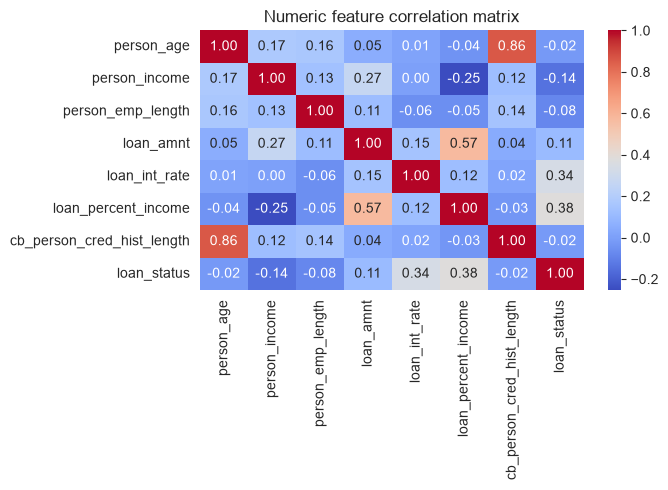

In [7]:
check = (df['loan_amnt'] / df['person_income'])
print('corr(loan_percent_income, loan_amnt/person_income):', check.corr(df['loan_percent_income']))
print()
num_corr = df[NUMERIC_COLS + [TARGET]].corr()[TARGET].sort_values()
print(num_corr)
plt.figure(figsize=(7, 5))
sns.heatmap(df[NUMERIC_COLS + [TARGET]].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Numeric feature correlation matrix')
plt.tight_layout()
plt.show()

**Finding:** `loan_percent_income` correlates 0.999 with `loan_amnt / person_income`
— it *is* that ratio, already provided. No need to re-engineer it (avoids adding a
redundant column that would just inflate the feature count for no informational
gain). `loan_int_rate` (r=0.34) and `loan_percent_income` (r=0.38) are the strongest
linear numeric correlates with default; `person_age` and `cb_person_cred_hist_length`
are weakly correlated (~-0.02) — expected to have low IV, will confirm in notebook 02.

## 6. Apply cleaning and split

In [8]:
df_clean = clean(df)
print('duplicates dropped:', df_clean.attrs['n_duplicates_dropped'])
print('ages capped:', df_clean.attrs['n_age_capped'])
print('emp_length fixed:', df_clean.attrs['n_emp_length_fixed'])
print('shape after cleaning:', df_clean.shape)

duplicates dropped: 165
ages capped: 7
emp_length fixed: 2
shape after cleaning: (32416, 12)


In [9]:
# 60 / 20 / 20 stratified split. Home Credit-style out-of-time validation is not
# possible here either — this dataset has no origination date column at all, not
# even a usable proxy. Documented limitation, not silently ignored: a production
# deployment of this model would need OOT validation once real timestamped data is
# available, because economic conditions and lending policy drift over time.
X, y = get_feature_target(df_clean)

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42
)  # 0.25 of the remaining 80% = 20% of the total

print('train:', X_train.shape, 'val:', X_val.shape, 'test:', X_test.shape)
print('train target rate:', y_train.mean().round(4))
print('val   target rate:', y_val.mean().round(4))
print('test  target rate:', y_test.mean().round(4))

train: (19449, 11) val: (6483, 11) test: (6484, 11)
train target rate: 0.2187
val   target rate: 0.2187
test  target rate: 0.2187


## 7. Impute missing values (fit on train only, applied to val/test)

`loan_int_rate` is imputed **within `loan_grade` group** rather than with a single
global median: grade and interest rate correlate at r=0.93 (Section 5-adjacent check
below), so a grade-conditional median is a much better estimate than a flat one.
`person_emp_length` uses a plain train-median (no similarly strong conditioning
variable found).

In [10]:
grade_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6}
print('corr(grade_ordinal, loan_int_rate):', df_clean['loan_grade'].map(grade_map).corr(df_clean['loan_int_rate']))

int_rate_by_grade = X_train.groupby('loan_grade')['loan_int_rate'].median()
print(int_rate_by_grade)

emp_length_median = X_train['person_emp_length'].median()
print('person_emp_length train median:', emp_length_median)

corr(grade_ordinal, loan_int_rate): 0.9337207624220126
loan_grade
A     7.49
B    10.99
C    13.48
D    15.32
E    16.77
F    18.43
G    20.11
Name: loan_int_rate, dtype: float64
person_emp_length train median: 4.0


In [11]:
def impute(X, int_rate_by_grade, emp_length_median):
    X = X.copy()
    X['loan_int_rate'] = X['loan_int_rate'].fillna(X['loan_grade'].map(int_rate_by_grade))
    X['loan_int_rate'] = X['loan_int_rate'].fillna(int_rate_by_grade.median())  # safety net for an unseen grade
    X['person_emp_length'] = X['person_emp_length'].fillna(emp_length_median)
    return X

X_train = impute(X_train, int_rate_by_grade, emp_length_median)
X_val = impute(X_val, int_rate_by_grade, emp_length_median)
X_test = impute(X_test, int_rate_by_grade, emp_length_median)

assert X_train.isnull().sum().sum() == 0
assert X_val.isnull().sum().sum() == 0
assert X_test.isnull().sum().sum() == 0
print('no missing values remain in any split')

no missing values remain in any split


## 8. Save processed splits

In [12]:
import os
os.makedirs('../data/processed', exist_ok=True)

for name, Xs, ys in [('train', X_train, y_train), ('val', X_val, y_val), ('test', X_test, y_test)]:
    out = Xs.copy()
    out[TARGET] = ys.values
    out.to_csv(f'../data/processed/{name}.csv', index=False)
    print(f'saved data/processed/{name}.csv', out.shape)

saved data/processed/train.csv (19449, 12)


saved data/processed/val.csv (6483, 12)
saved data/processed/test.csv (6484, 12)


## Summary

- Loaded 32,581 raw rows / 12 columns; confirmed target imbalance (78.2% / 21.8%).
- Cleaned: 165 duplicates dropped, 7 implausible ages capped, 2 impossible
  emp_length values fixed — all documented and justified above, none silently done.
- Confirmed `loan_percent_income` is a pre-existing ratio (no redundant engineering
  needed) and flagged `loan_grade` as a very strong, legitimate-but-dominant
  predictor requiring an ablation model later for a defensible story.
- Missing values (`loan_int_rate`, `person_emp_length`) imputed using train-only
  statistics (grade-conditional median for interest rate) — no leakage.
- Produced a 60/20/20 stratified train/val/test split, saved to `data/processed/`,
  ready for baseline modeling in notebook 02.